# Tanqeeb Egypt Jobs Dataset — Complete EDA Notebook

## Overview
This notebook analyzes 833 job listings scraped from Tanqeeb Egypt covering job titles, companies, locations, and skills.

## Objectives
- Audit and clean the dataset.
- Analyze top companies, locations, and skills.
- Explore job-title patterns and skill demand.
- Build a word cloud and token frequency analysis.
- Export clean summary CSVs.


In [1]:
import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

RANDOM_STATE = 42
print("Environment ready")

Environment ready


In [2]:
# Auto-detect file path for Kaggle or local
possible_paths = [
    '/kaggle/input/tanqeeb-egypt-jobs-dataset-web-scraping-csv/tanqeeb_jobs.csv',
    '/kaggle/input/tanqeeb-jobs-dataset/tanqeeb_jobs.csv',
    'tanqeeb_jobs.csv'
]
csv_path = None
for p in possible_paths:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    for dirname, _, filenames in os.walk('/kaggle/input'):
        for filename in filenames:
            if filename.endswith('.csv'):
                csv_path = os.path.join(dirname, filename)
                break
    if csv_path is None:
        raise FileNotFoundError("CSV file not found!")

df = pd.read_csv(csv_path)
print("Loaded:", df.shape)
print(df.head())

Loaded: (833, 5)
                           job title company name  \
0                AI Academy Vodafone     Vodafone   
1            Senior Business Analyst        dopay   
2  Junior Solution Architect  RedHat          NaN   
3                Intern AI Technical      Tamatem   
4                   SCC V&V Engineer       Alstom   

                                           location  \
0  Egypt                                    , Egypt   
1  Egypt                                    , Cairo   
2  Egypt                                    , Cairo   
3                                             Egypt   
4  Egypt                                    , Egypt   

                                   skills  \
0                           Not Mentioned   
1  Business Intelligence & Data Analytics   
2                           Not Mentioned   
3             Arabic AI & NLP Engineering   
4                           Not Mentioned   

                                         detail link  
0  http

In [3]:
print("\n" + "="*80)
print("DATA QUALITY AUDIT")
print("="*80)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Columns list:", df.columns.tolist())
print("Missing values total:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nDtypes:\n", df.dtypes)
print("\nSample stats:\n", df.describe(include="all").T)


DATA QUALITY AUDIT
Rows: 833
Columns: 5
Columns list: ['job title', 'company name', 'location', 'skills', 'detail link']
Missing values total: 391
Duplicate rows: 0

Dtypes:
 job title       object
company name    object
location        object
skills          object
detail link     object
dtype: object

Sample stats:
              count unique                                                top  \
job title      777    561                               Senior Data Engineer   
company name   738    332                                           Joveo Ai   
location       779     11   Egypt                                    , Cairo   
skills         647     51                                          Full Time   
detail link    833    833  https://egypt.tanqeeb.com/jobs-in-middle-east/...   

             freq  
job title      19  
company name   32  
location      543  
skills        346  
detail link     1  


In [4]:
df_clean = df.copy()
df_clean.columns = [c.strip().lower().replace(" ", "_") for c in df_clean.columns]
for col in df_clean.columns:
    if df_clean[col].dtype == "object":
        df_clean[col] = df_clean[col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
for col in df_clean.columns:
    df_clean[col] = df_clean[col].replace({"nan": np.nan, "None": np.nan, "": np.nan})
for col in df_clean.columns:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna("Unknown")
print("Clean shape:", df_clean.shape)
print("Remaining missing:", df_clean.isnull().sum().sum())
print("Clean columns:", df_clean.columns.tolist())

Clean shape: (833, 5)
Remaining missing: 0
Clean columns: ['job_title', 'company_name', 'location', 'skills', 'detail_link']


In [5]:
# Build top-count DataFrames using value_counts() — columns: [category_name, "count"]
def top_counts(series, n=15):
    return series.value_counts().head(n).reset_index()

company_counts  = top_counts(df_clean["company_name"], 15)
location_counts = top_counts(df_clean["location"], 15)
skill_counts    = top_counts(df_clean["skills"], 20)
job_title_counts = top_counts(df_clean["job_title"], 20)

cat_col_company  = company_counts.columns[0]
cat_col_location = location_counts.columns[0]
cat_col_skills   = skill_counts.columns[0]
cat_col_jobs     = job_title_counts.columns[0]
val_col          = "count"

print("company_counts columns:", company_counts.columns.tolist())
print(company_counts.head())

company_counts columns: ['company_name', 'count']
       company_name  count
0           Unknown     95
1          Joveo Ai     32
2  Vodafone - Egypt     27
3            Turing     23
4     Sana Commerce     18


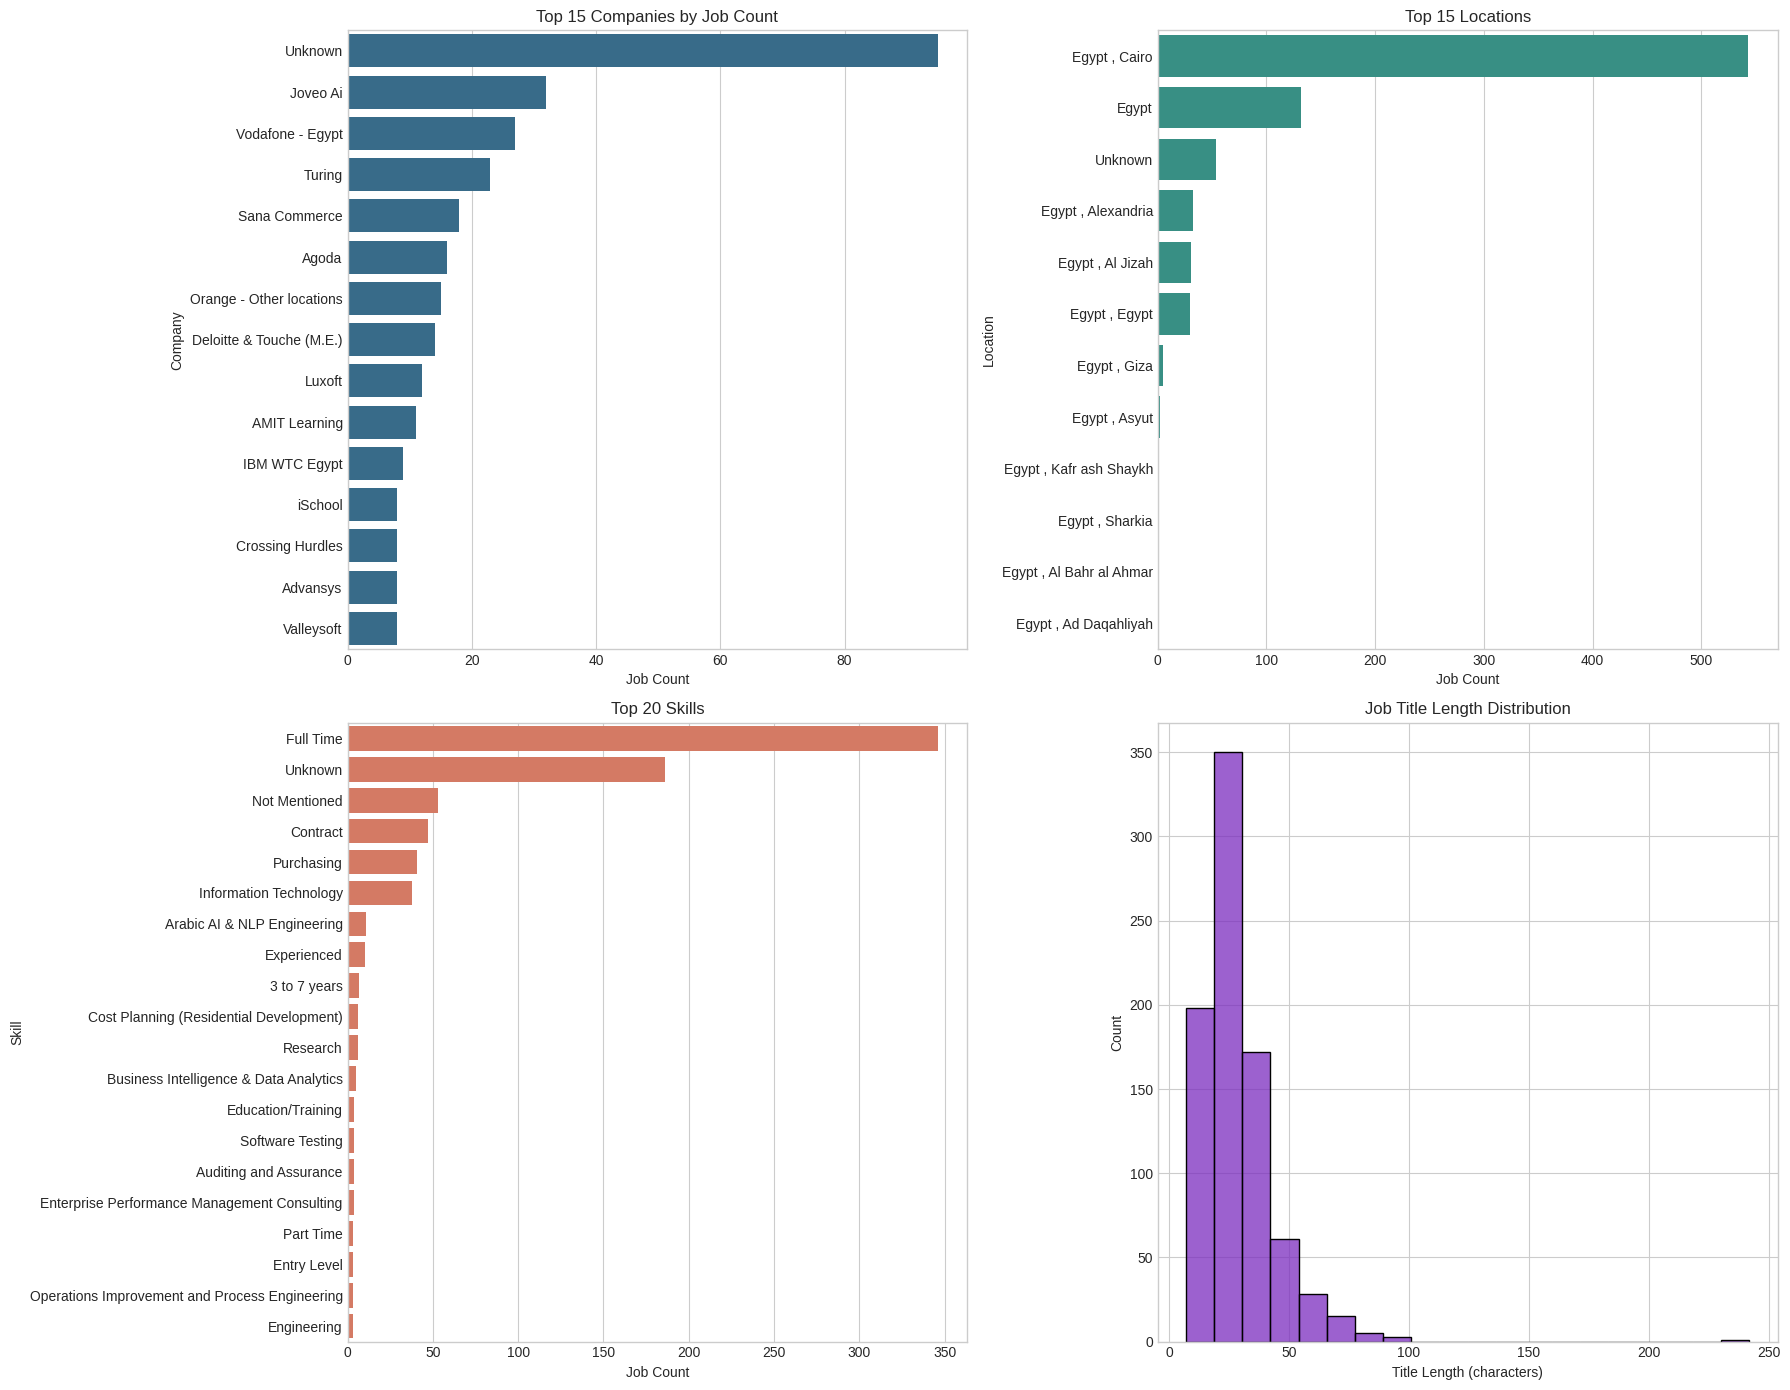

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

sns.barplot(data=company_counts,  y=cat_col_company,  x=val_col, ax=axes[0,0], color="#2a6f97")
axes[0,0].set_title("Top 15 Companies by Job Count")
axes[0,0].set_xlabel("Job Count")
axes[0,0].set_ylabel("Company")

sns.barplot(data=location_counts, y=cat_col_location, x=val_col, ax=axes[0,1], color="#2a9d8f")
axes[0,1].set_title("Top 15 Locations")
axes[0,1].set_xlabel("Job Count")
axes[0,1].set_ylabel("Location")

sns.barplot(data=skill_counts,    y=cat_col_skills,   x=val_col, ax=axes[1,0], color="#e76f51")
axes[1,0].set_title("Top 20 Skills")
axes[1,0].set_xlabel("Job Count")
axes[1,0].set_ylabel("Skill")

job_len = df_clean["job_title"].str.len()
sns.histplot(job_len, bins=20, ax=axes[1,1], color="#7b2cbf")
axes[1,1].set_title("Job Title Length Distribution")
axes[1,1].set_xlabel("Title Length (characters)")
axes[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()

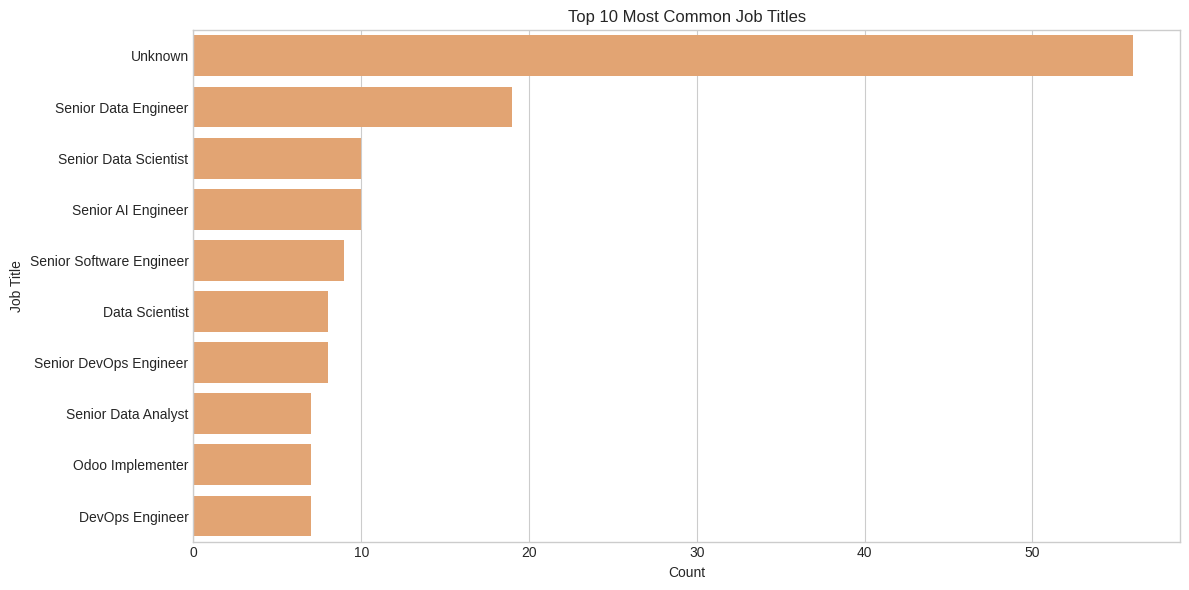

In [7]:
# Top 10 job titles bar chart
top_titles = job_title_counts.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_titles, y=cat_col_jobs, x=val_col, color="#f4a261")
plt.title("Top 10 Most Common Job Titles")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()

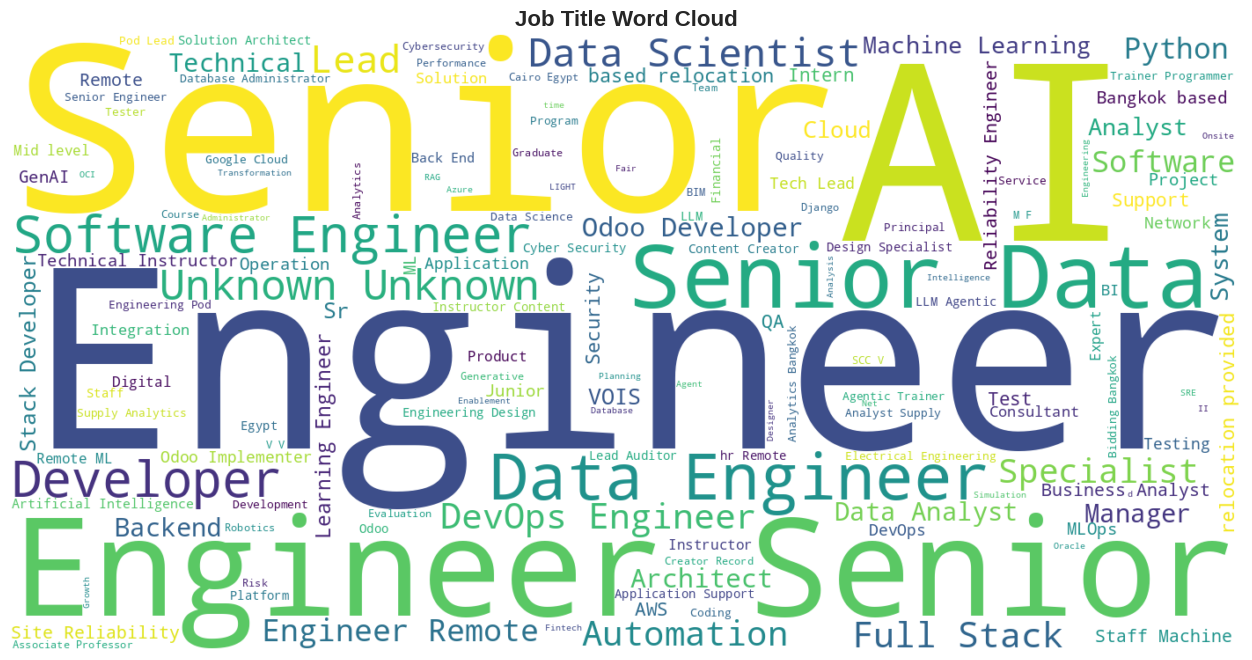

In [8]:
# Word Cloud from job titles
wordcloud_text = " ".join(df_clean["job_title"].astype(str).tolist())
wc = WordCloud(width=1400, height=700, background_color="white", colormap="viridis", max_words=150).generate(wordcloud_text)
plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Job Title Word Cloud", fontsize=16, fontweight="bold")
plt.show()

In [9]:
# Token frequency analysis
def extract_tokens(series, min_len=3):
    words = []
    for x in series.dropna().astype(str):
        words.extend([w for w in re.findall(r"[A-Za-z#+&/.-]+", x.lower()) if len(w) >= min_len])
    return Counter(words)

title_word_counts = extract_tokens(df_clean["job_title"])
skill_word_counts = extract_tokens(df_clean["skills"])

print("\nTop 30 Title Tokens:")
print(pd.DataFrame(title_word_counts.most_common(30), columns=["word", "count"]).to_string(index=False))

print("\nTop 30 Skill Tokens:")
print(pd.DataFrame(skill_word_counts.most_common(30), columns=["word", "count"]).to_string(index=False))


Top 30 Title Tokens:
       word  count
   engineer    379
     senior    237
       data    142
  developer     80
   software     75
    unknown     56
    analyst     54
       lead     54
     remote     53
  scientist     40
     devops     39
       odoo     36
 specialist     35
  technical     30
 automation     29
  architect     27
       full     27
     python     25
      stack     24
 instructor     23
      cloud     22
        and     20
    backend     20
    manager     20
engineering     19
   security     19
    machine     18
   learning     18
    support     18
       vois     16

Top 30 Skill Tokens:
              word  count
              time    349
              full    346
           unknown    186
               not     53
         mentioned     53
          contract     47
        purchasing     41
       information     38
        technology     38
             years     26
       engineering     19
               and     13
            arabic     11
   

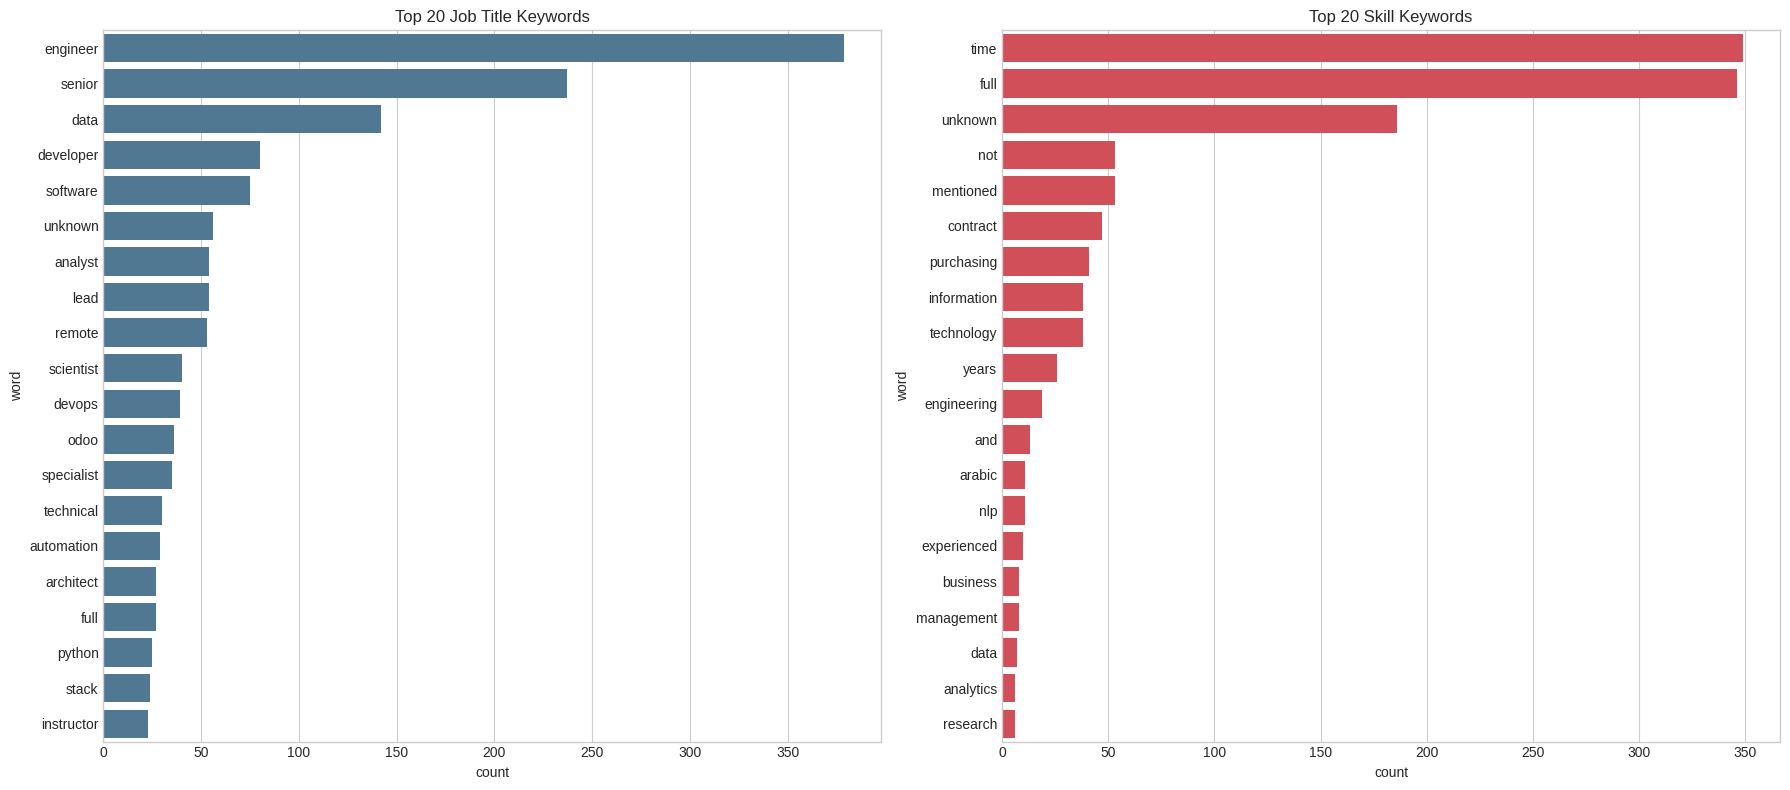

In [10]:
# Token frequency bar charts
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

title_df = pd.DataFrame(title_word_counts.most_common(20), columns=["word", "count"])
skill_df  = pd.DataFrame(skill_word_counts.most_common(20), columns=["word", "count"])

sns.barplot(data=title_df, y="word", x="count", ax=axes[0], color="#457b9d")
axes[0].set_title("Top 20 Job Title Keywords")

sns.barplot(data=skill_df, y="word", x="count", ax=axes[1], color="#e63946")
axes[1].set_title("Top 20 Skill Keywords")

plt.tight_layout()
plt.show()

In [11]:
# Summary statistics table
summary = pd.DataFrame({
    "metric": ["total_jobs", "unique_companies", "unique_locations", "unique_skills", "unique_job_titles"],
    "value":  [
        len(df_clean),
        df_clean["company_name"].nunique(),
        df_clean["location"].nunique(),
        df_clean["skills"].nunique(),
        df_clean["job_title"].nunique()
    ]
})
display(summary)

,metric,value
0,total_jobs,833
1,unique_companies,333
2,unique_locations,12
3,unique_skills,52
4,unique_job_titles,561


In [12]:
# Export CSVs
os.makedirs("/kaggle/working/output", exist_ok=True)
summary.to_csv("/kaggle/working/output/tanqeeb_summary.csv", index=False)
company_counts.to_csv("/kaggle/working/output/top_companies.csv", index=False)
location_counts.to_csv("/kaggle/working/output/top_locations.csv", index=False)
skill_counts.to_csv("/kaggle/working/output/top_skills.csv", index=False)
print("All CSVs saved to /kaggle/working/output/")

All CSVs saved to /kaggle/working/output/


## Key Insights
- **Company demand**: A few companies post the majority of jobs — useful for recruitment targeting.
- **Skill sparsity**: Many rows have "Not Mentioned" skills, making job-title tokenization the primary signal.
- **Location patterns**: Most listings are in Egypt/Cairo, confirming a local market dataset.
- **Job-title variety**: Technology, data, and business-analysis roles dominate.

## Next Steps
- Normalize city names from the messy `location` strings.
- Split multi-skill comma-separated strings into individual skill tokens.
- Build a job-family classifier using title keywords.
- Add TF-IDF vectorization for skill/title similarity search.
